# Basic Example using MOGPTK

Basics of defining, fitting, and plotting results of MOGPTK model.

In [25]:
import numpy as np 
import torch
import mogptk

torch.manual_seed(1);

$$k_{ij}(\tau) = \sum_{q=1}^Q \alpha^{(q)}_{ij} \exp \left( -\frac{1}{2} (\tau + \theta^{(q)}_{ij})^\top \Sigma^{(q)}_{ij}(\tau + \theta^{(q)}_{ij}) \right) \cos \left( (\tau + \theta^{(q)}_{ij})^\top \mu^{(q)}_{ij} + \phi^{(q)}_{ij} \right), \qquad \alpha^{(q)}_{ij} = w^{(q)}_{ij} (2\pi)^{n/2} | \Sigma^{(q)}_{ij} |^{1/2} $$

- No. of spectral mixture components: $Q$
- Covariance: $\Sigma_{ij}$
- Mean: $\mu_{ij}$
- Magnitude (weight of component): $w_{ij}$
- Delay: $\theta_{ij} = \theta_i - \theta_j$
- Phase: $\phi_{ij} = \phi_i - \phi_j$

## Quickstart Example

In [26]:
n_points = 100
t = np.linspace(0.0, 6.0, n_points)

y1 = np.sin(6.0*t) + 0.2*np.random.normal(size=len(t))
y2 = np.sin(6.0*t + 2.0) + 0.2*np.random.normal(size=len(t))
y3 = np.sin(6.0 * (t-2.0)) + 0.2*np.random.normal(size=len(t))
y4 = np.sin(6.0 * (t-2.0) + 2.0) + 0.2*np.random.normal(size=len(t))
y5 = np.sin(6.0*t) - np.sin(4.0*t) + 0.2*np.random.normal(size=len(t)) 


# create dataset
dataset = mogptk.DataSet(
    mogptk.Data(t, y1, name='Sinusoid'),
    mogptk.Data(t, y2, name='Phase shifted'),
    mogptk.Data(t, y3, name='Delayed'),
#    mogptk.Data(t, y4, name='Phase shifted and delayed')
    mogptk.Data(t, y5, name='Two sinusoids')
)

# remove 20% randomly
for data in dataset:
    data.remove_randomly(pct=0.2)

# remove later third of the first channel
dataset[0].remove_range(start=4.0)

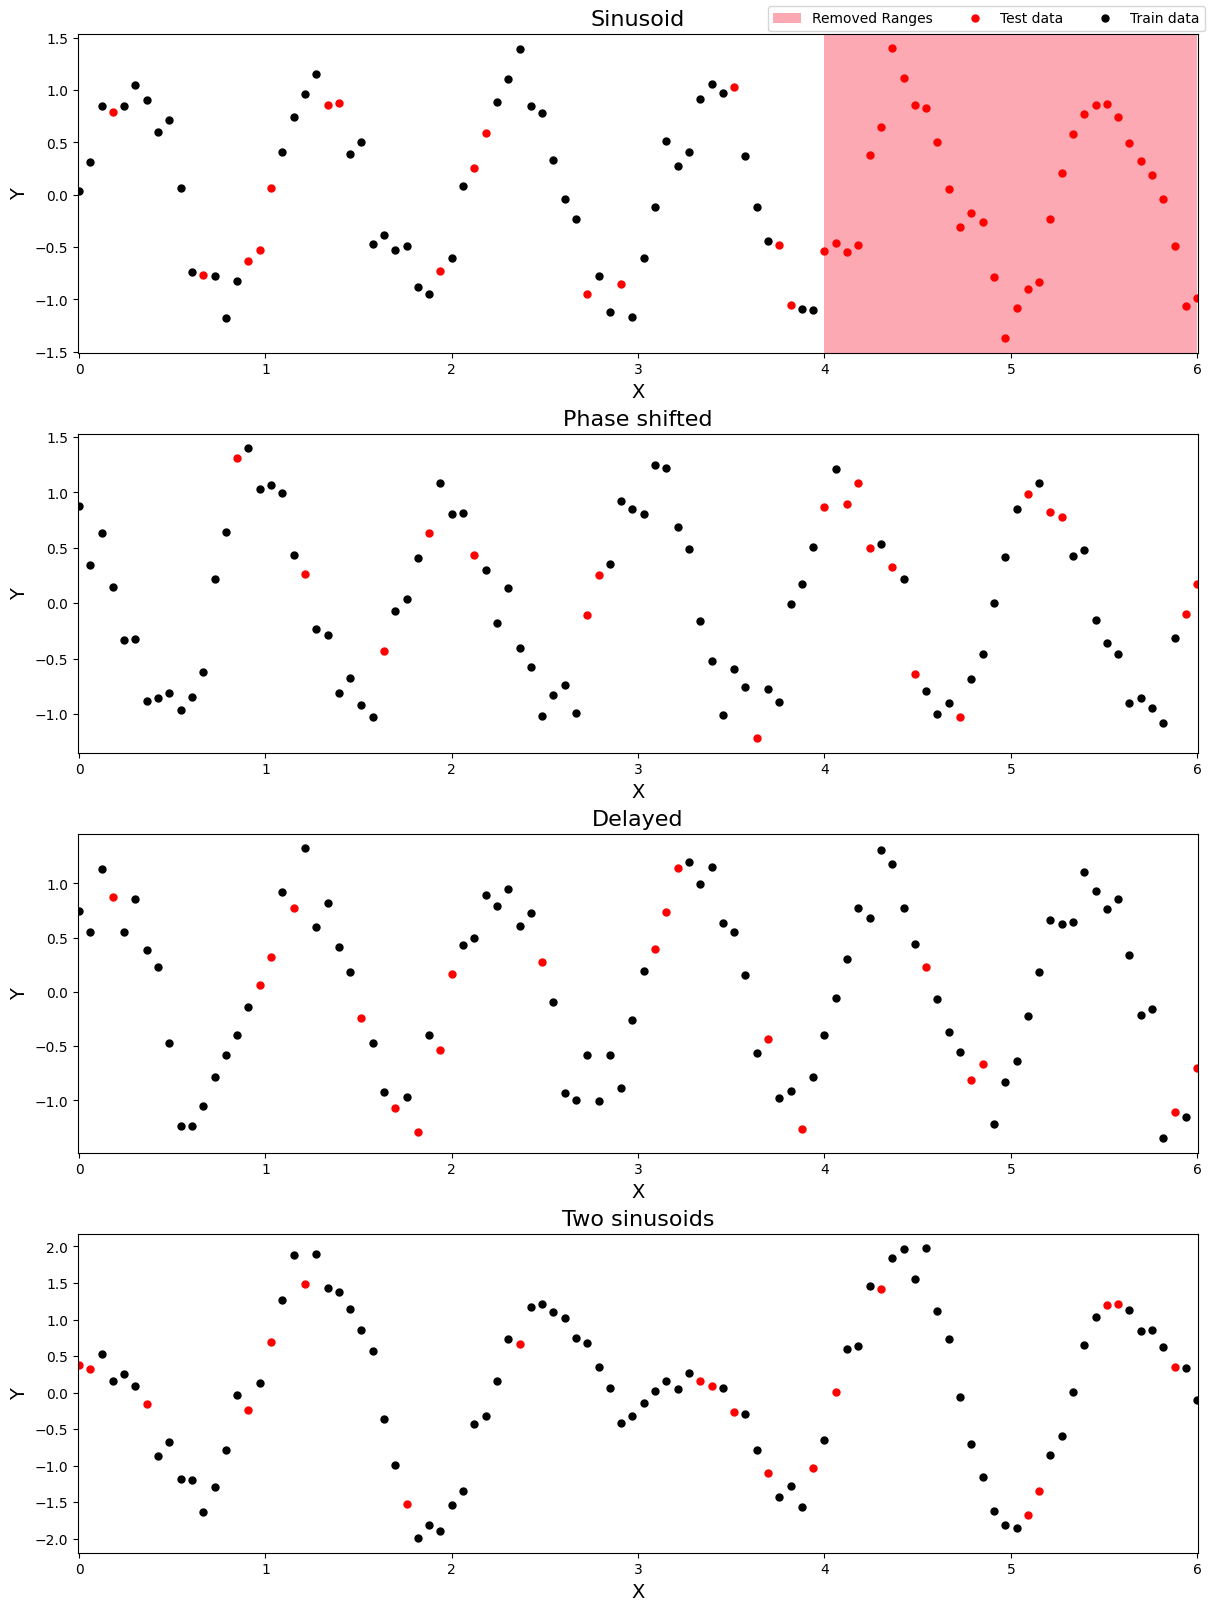

In [27]:
dataset.plot();

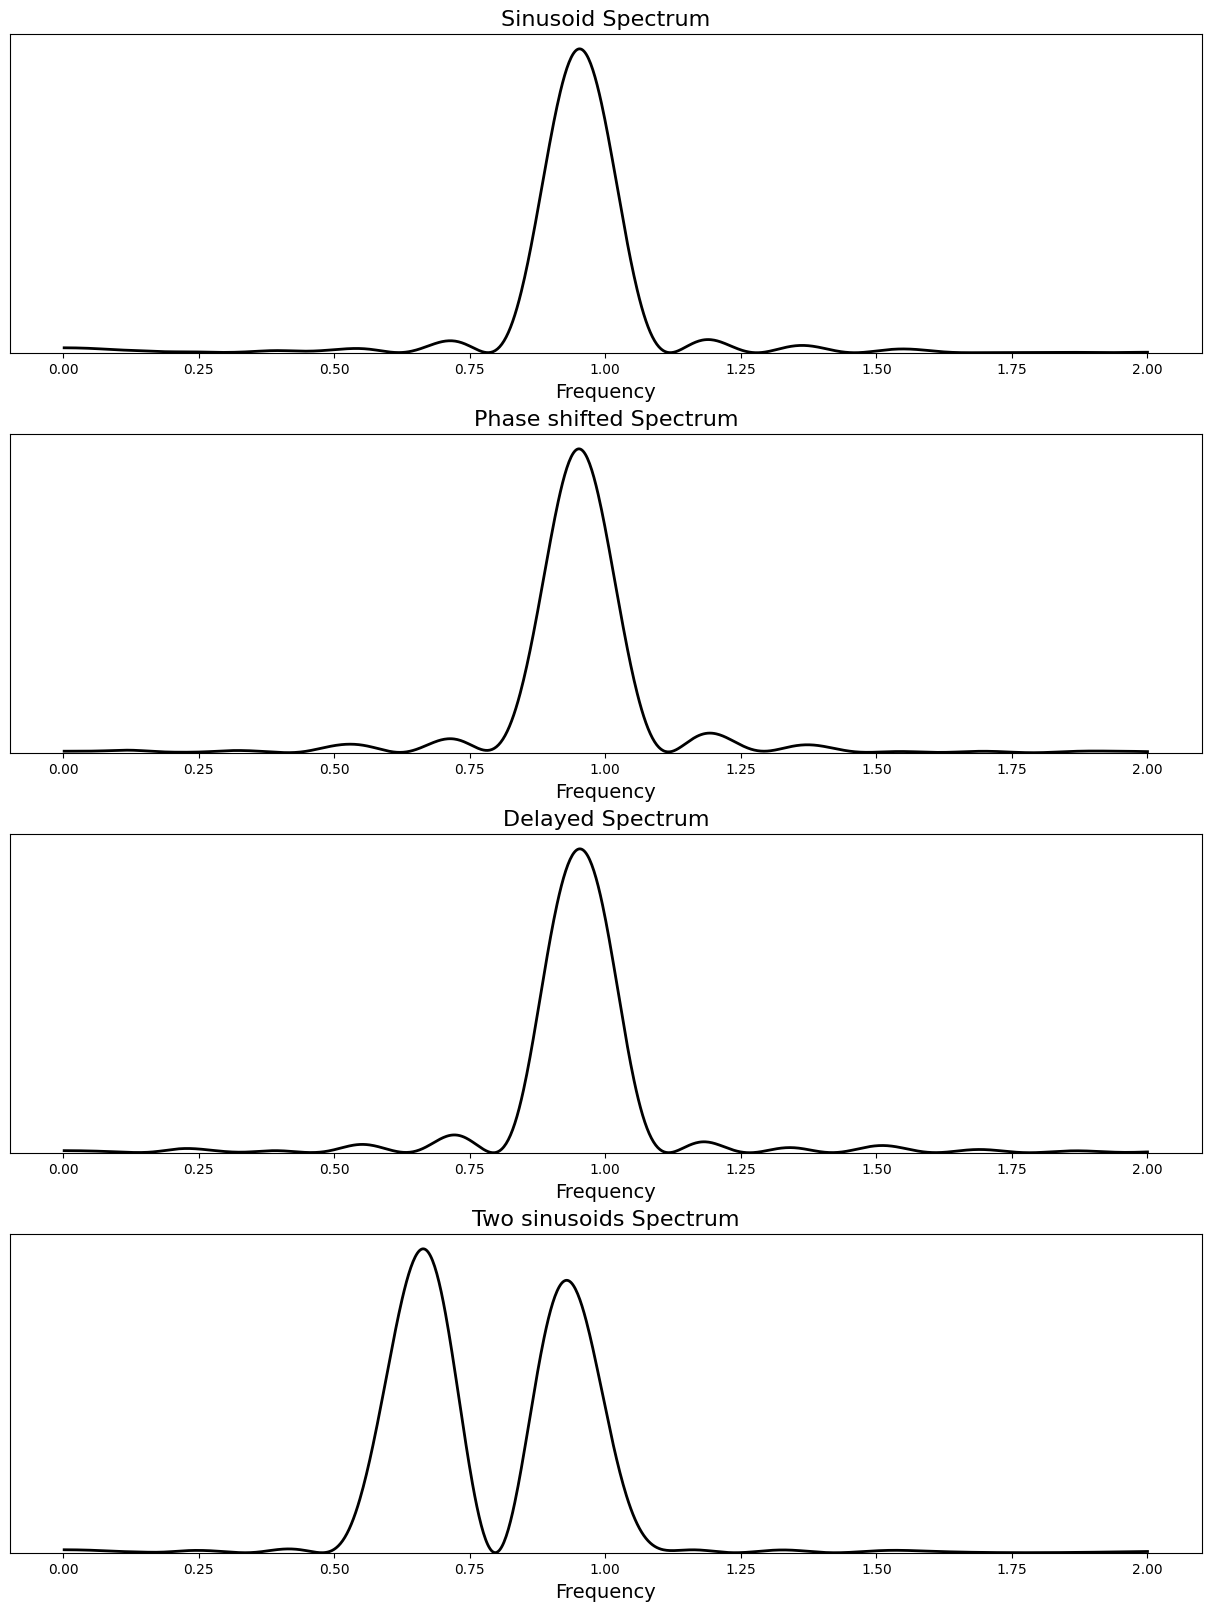

In [28]:
# LS periodogram
dataset.plot_spectrum(maxfreq=2);

In [29]:
# create model, uncomment for different kernels 
# Q is the number of components in the mixture kernel

model = mogptk.MOSM(dataset, Q=2)
# model = mogptk.CSM(dataset, Q=2)
# model = mogptk.SM_LMC(dataset, Q=2)
# model = mogptk.CONV(dataset, Q=2)

# initialize parameters of kernel using LombScargle
model.init_parameters(method='LS', iters=500)

model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[10.31688092 3.19029833] [ 9.92720981 2.56522917] [10.38093426 2.67075987] [11.56007117 10.77785643]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.9620462 ] [1.31683168]] [[0.95214521] [0.54620462]] [[0.95132013] [0.54125413]] [[0.6650165 ] [0.93234323]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00860195] [0.00420207]] [[0.00376579] [0.00244645]] [[0.00372736] [0.00216687]] [[0.00392115] [0.00378945]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[0.] [0.]] [[0.] [0.]] [[0.] [0.]] [[0.] [0.]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[0. 0.] [0. 0.] [0. 0.] [0. 0.]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.7483284 0.72883689 0.7588502 1.06312739]


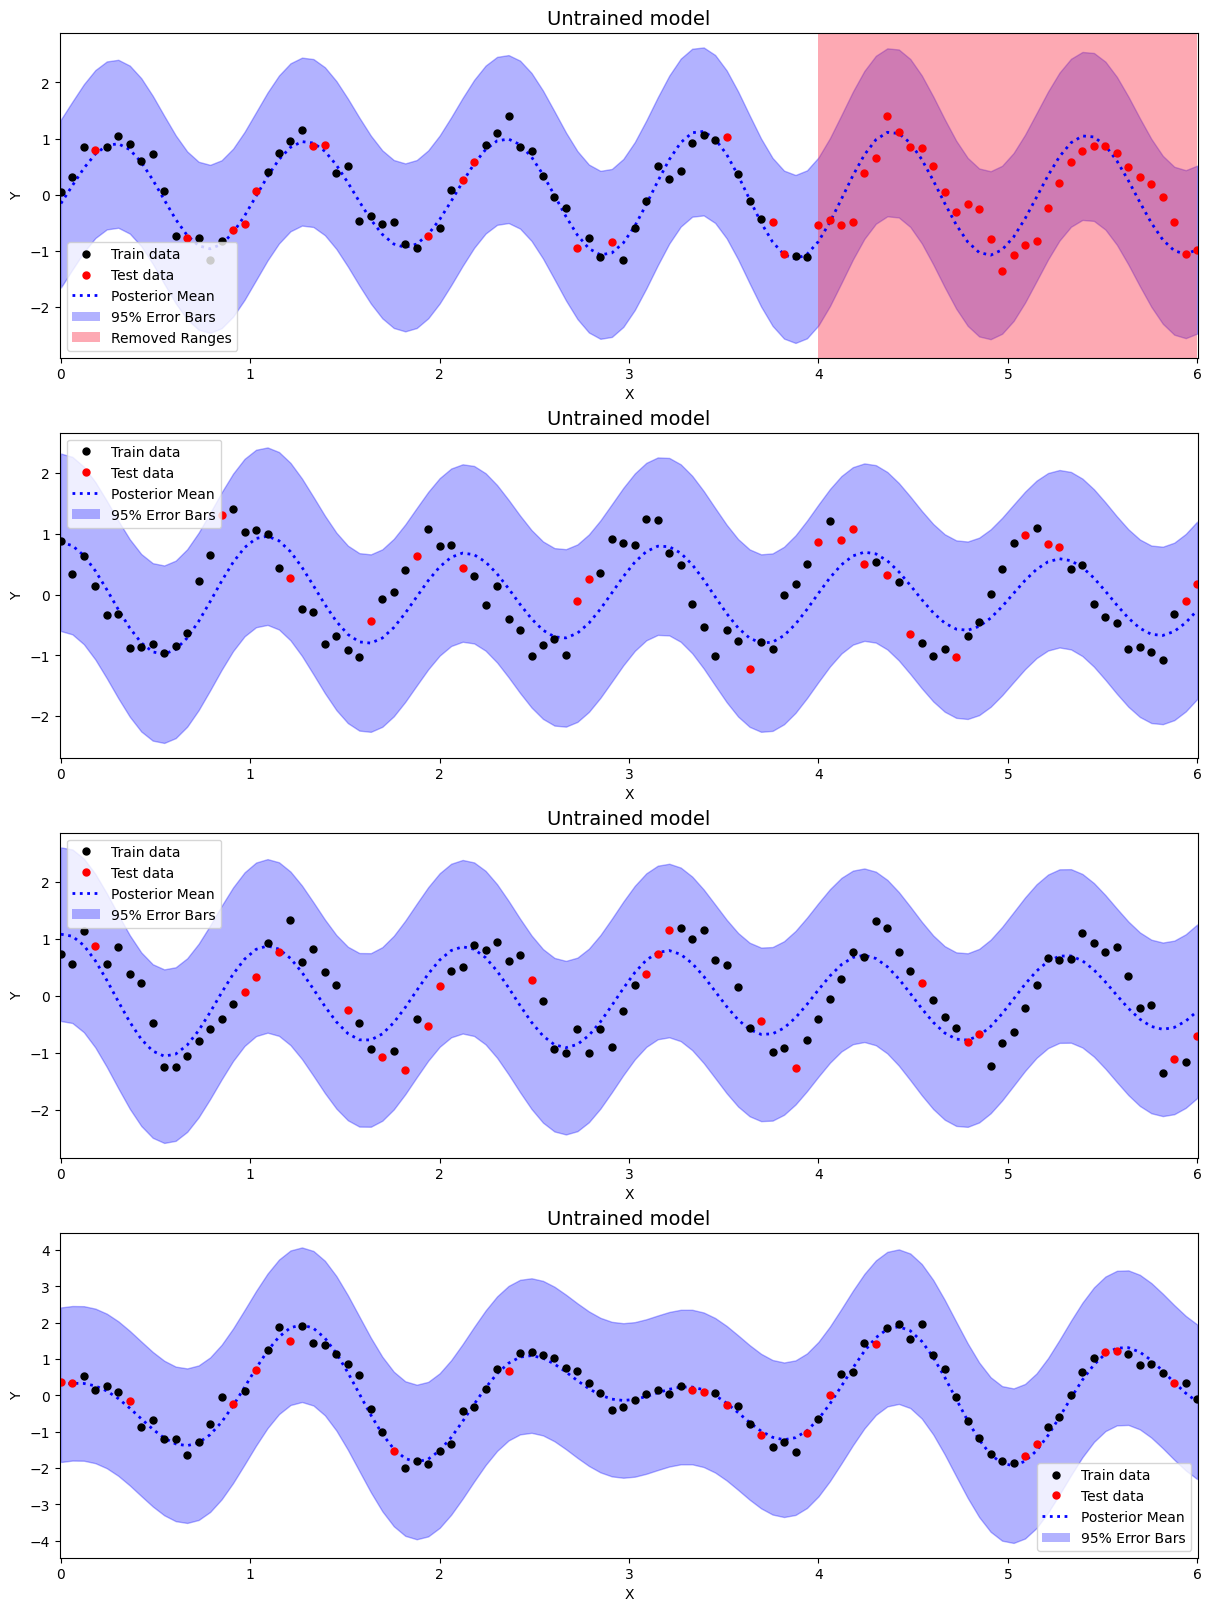

In [30]:
# plot the prediction with the untrained model
model.plot_prediction(title='Untrained model');

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 4
‣ Parameters: 44
‣ Training points: 291
‣ Iterations: 1000
     0/1000   0:00:00  loss=     292.609  error=    0.316901 (warmup)
   614/1000   0:00:10  loss=     20.5898  error=    0.166033
  1000/1000   0:00:15  loss=    -18.6333  error=    0.178957
Optimization finished in 15.970 seconds


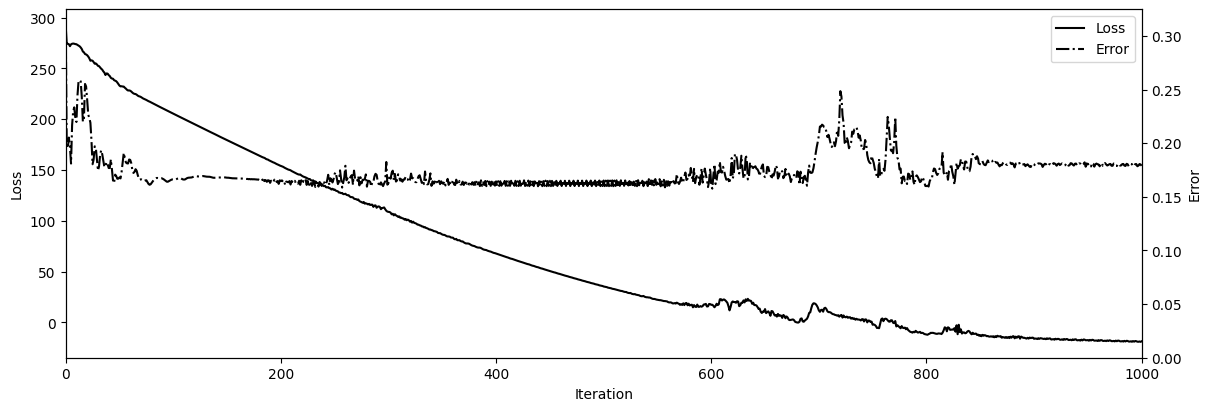

In [31]:
# Train the model
model.train(method='Adam', lr=0.02, iters=1000, plot=True, error='MAE', verbose=True);

In [32]:
model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[5.11446373 0.8210027 ] [4.31161572 0.45540432] [4.44278194 0.53325262] [3.03677568 3.02772713]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 8.250000000000007]",[[[0.95027143] [0.89000725]] [[0.95129102] [0.45918125]] [[0.953961 ] [0.45926955]] [[0.63821172] [0.95465083]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00391826] [0.00093861]] [[0.00375914] [0.00046285]] [[0.00374801] [0.00043371]] [[0.00073075] [0.00088717]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[-1.02266137e-01] [-2.69258396e-02]] [[ 3.78608583e-02] [ 1.85811942e-01]] [[-4.91987650e-02] [-1.85811942e-01]] [[-1.26975049e-11] [ 2.69258396e-02]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[-1.08416096e-01 -1.25825922e-01] [ 6.97314421e-02 -2.15351460e-02] [-6.40805172e-02 2.15351460e-02] [-1.74551892e-11 1.25825922e-01]]
GaussianLikelihood.scale,"[1e-08, ∞)",[0.20269671 0.20876273 0.21012608 0.22750049]


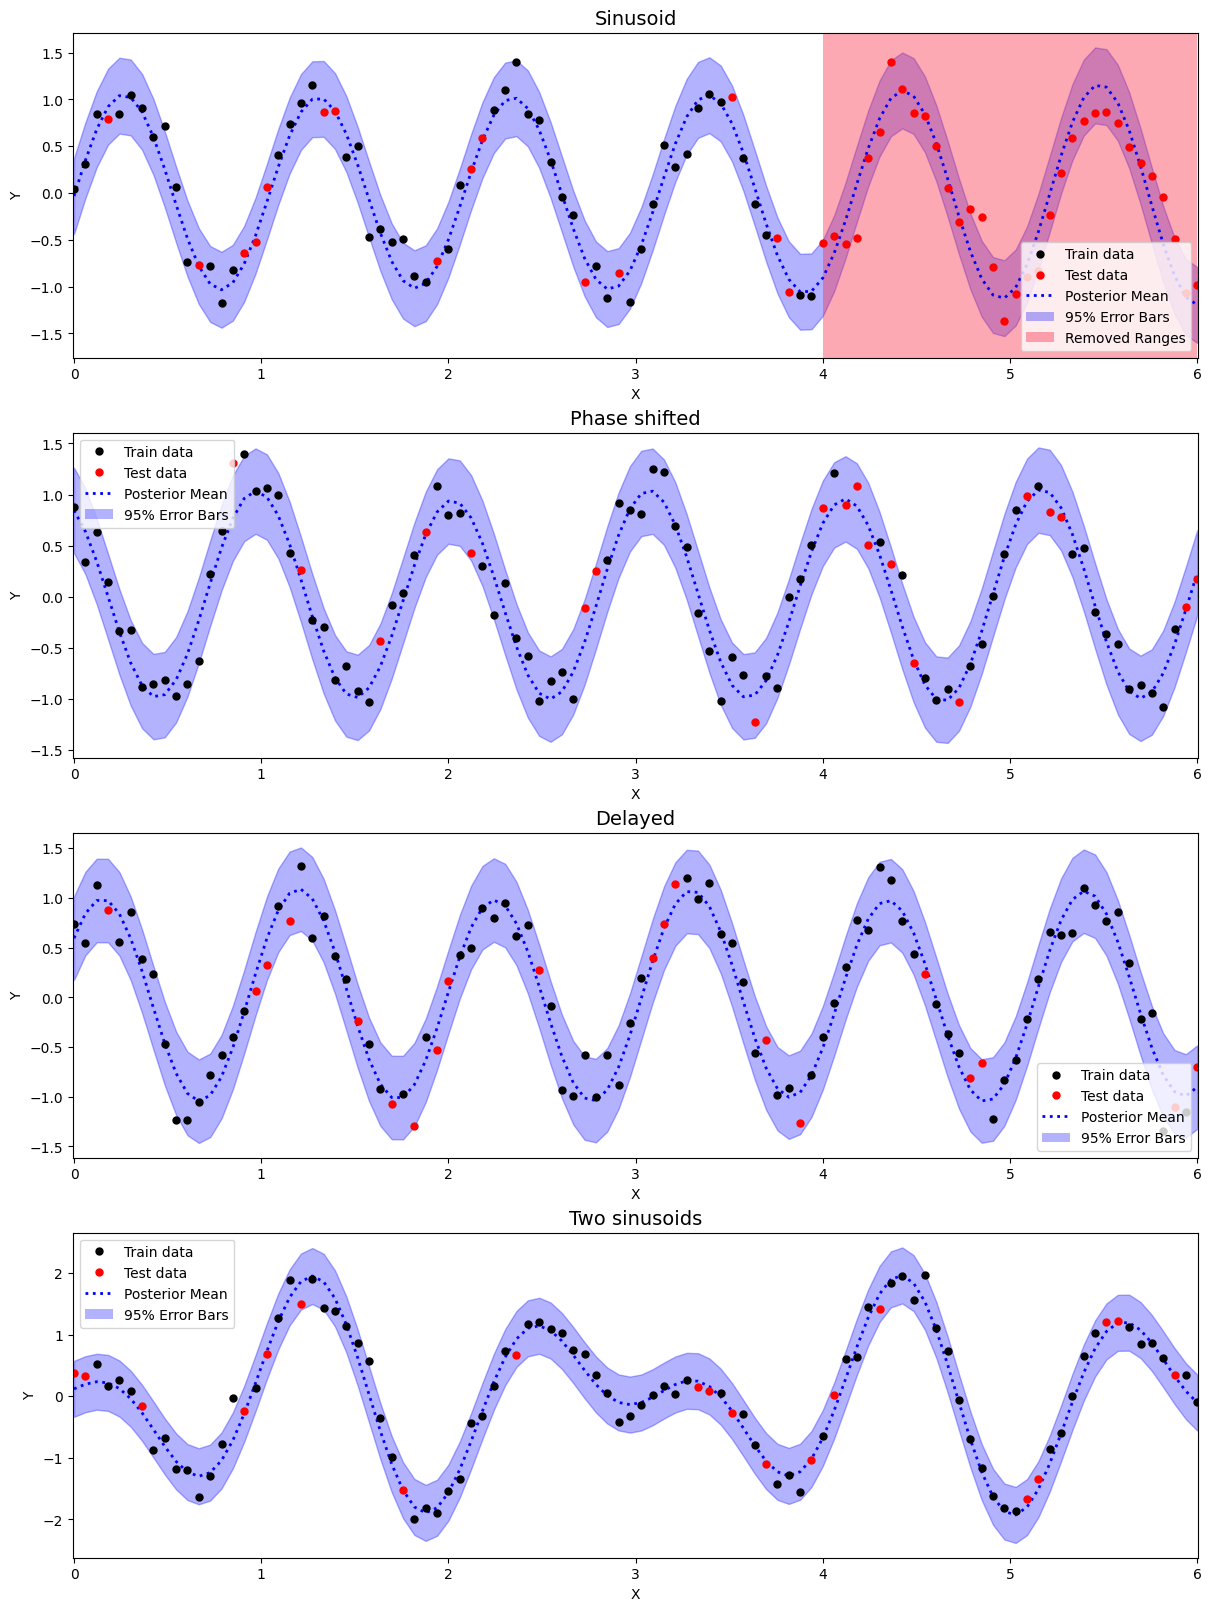

In [33]:
model.plot_prediction();

In [34]:
# prediction outside training range
# we use the same time for all the channels
t_pred = np.linspace(6.0, 10.0, 100)
x_pred = [t_pred for i in range(len(dataset))]
dataset.set_prediction_data(x_pred)

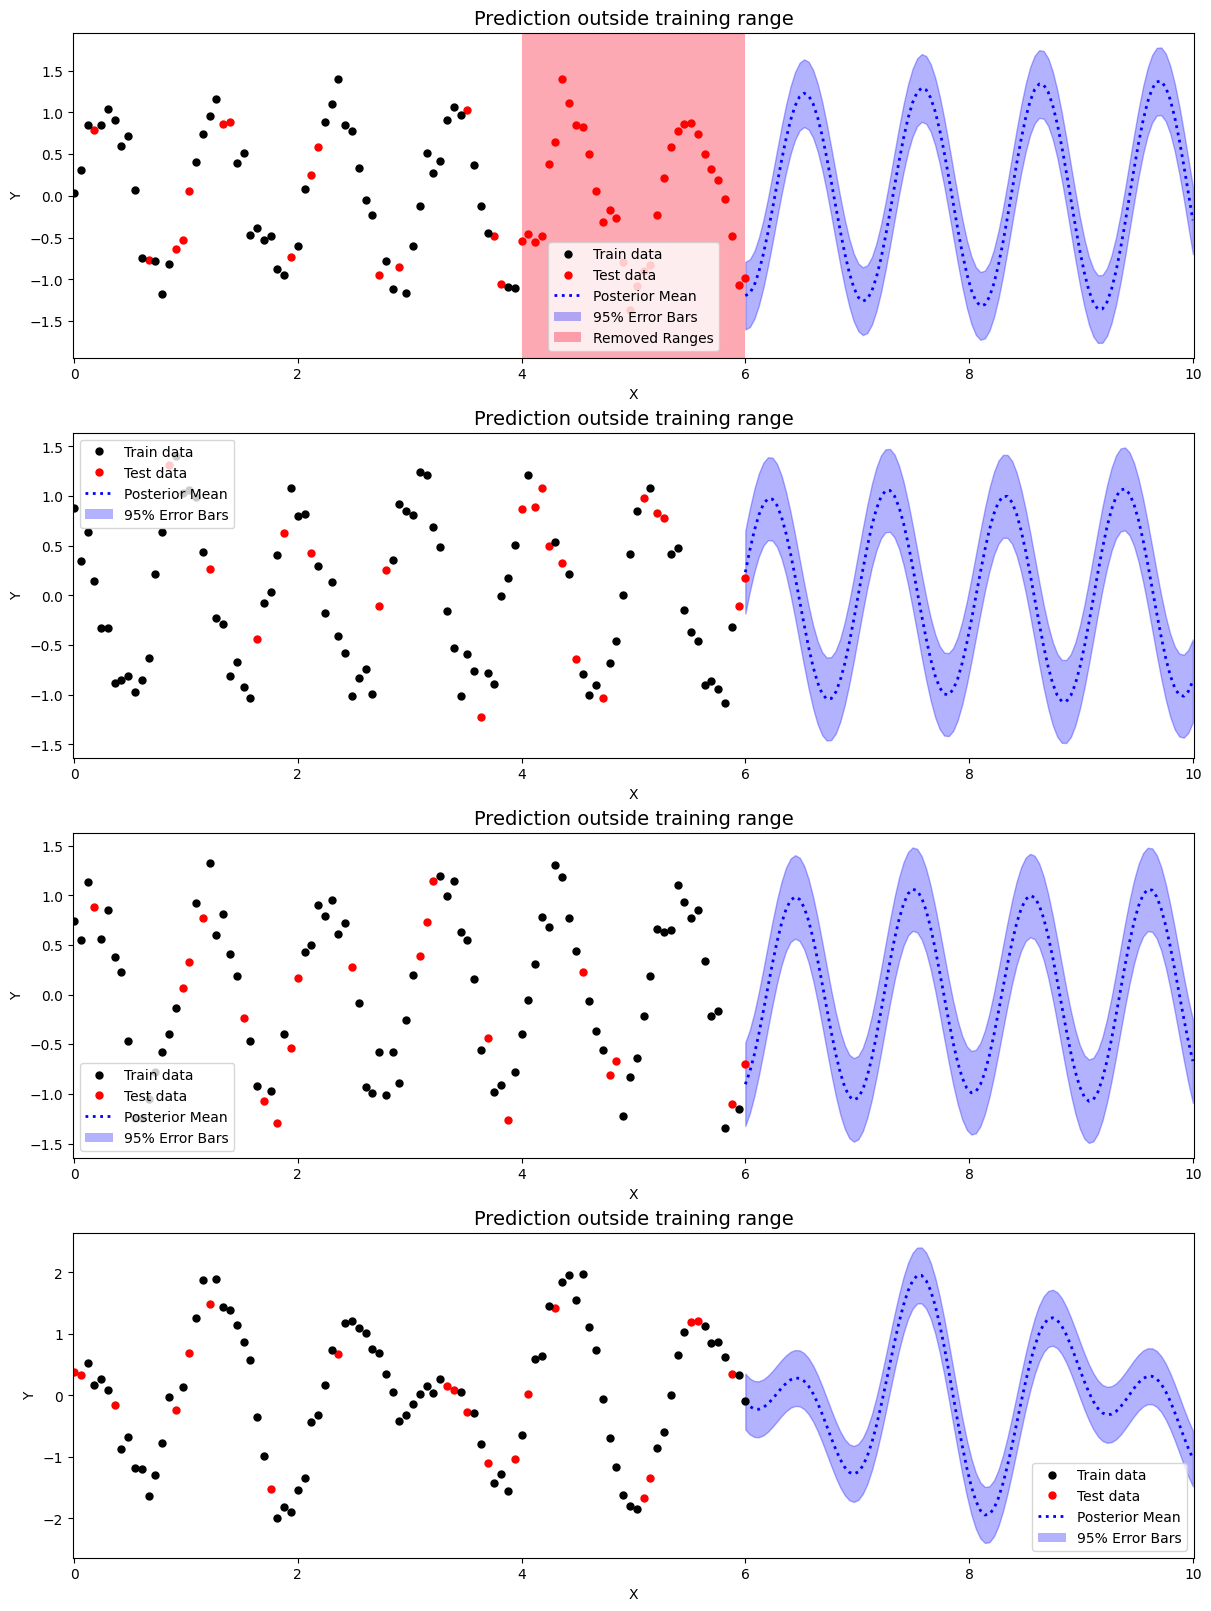

In [35]:
model.plot_prediction(title='Prediction outside training range');